In [28]:
import cv2
import matplotlib.pyplot as plt
import os

1. Hacer un programa que lea una imagen en escala de grises y
produzca el histograma correspondiente.

Cantidad de píxeles en la imagen: 533 x 800 = 426400


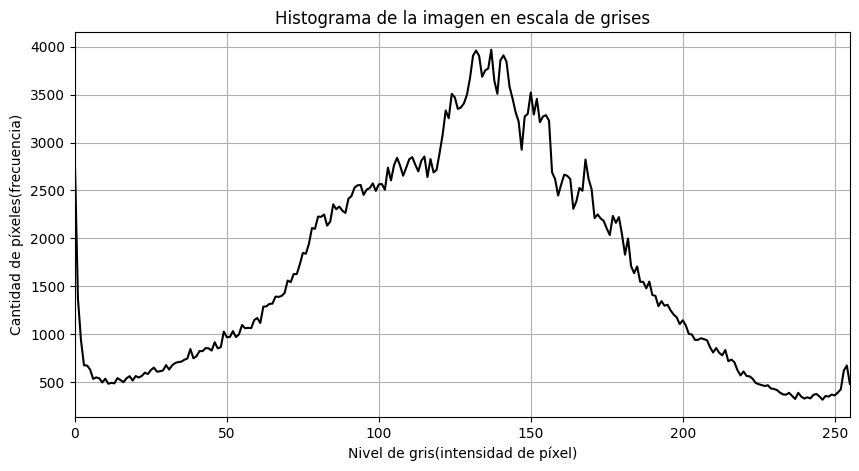

In [33]:
os.makedirs("resultados", exist_ok=True)

imagen_gris = cv2.imread("images/paisaje.png", cv2.IMREAD_GRAYSCALE)

# Primera forma manual de crear el histograma
def crear_histograma_manual(imagen):
    histograma = [0] * 256 # Cada posicion corresponde a un nivel de gris (0-255) y el valor en esa posicion es la cantidad de pixeles con ese nivel de gris

    filas,columnas = imagen.shape
    for i in range(filas):
        for j in range(columnas):
            nivel_gris = int(imagen[i,j]) # Convertimos el valor del pixel a entero
            histograma[nivel_gris] += 1 # Incrementamos el contador del nivel de gris correspondiente    
    return histograma

# Segunda forma de crear el histograma usando OpenCV
def crear_histograma_opencv(imagen):
    """
    calcHist necesita
    - imagen: lista de imágenes (en este caso solo una)
    - canales: lista de canales a usar (en este caso solo el canal 0)
    - mascara: None (no se usa máscara)
    - histSize: lista con la cantidad de bins o divisiones (en este caso 256)
    - rangos: lista con el rango de valores (intensidades) (en este caso de 0 a 256)
    """
    histograma = cv2.calcHist([imagen], [0], None, [256], [0, 256])
    return histograma


histograma_manual = crear_histograma_manual(imagen_gris)
histograma_opencv = crear_histograma_opencv(imagen_gris)
print(f"Cantidad de píxeles en la imagen: {imagen_gris.shape[0]} x {imagen_gris.shape[1]} = {imagen_gris.size}")


plt.figure(figsize=(10, 5))
plt.plot(range(256), histograma_opencv, color="black")
plt.title("Histograma de la imagen en escala de grises")
plt.xlabel("Nivel de gris(intensidad de píxel)")
plt.ylabel("Cantidad de píxeles(frecuencia)")
plt.xlim(0, 255)
plt.grid()
plt.savefig("resultados/histogramapt1.png")
plt.show()


